In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier # vecinos más cercanos para clasificación
from sklearn.metrics import accuracy_score # métrica de evaluación
from sklearn.metrics import classification_report

# Análisis Exploratorio

In [109]:
df_smokers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/smokers.csv')
df_smokers.head(5)

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,...,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,47,92,14.9,1,1.2,26,28,15,0,0


In [110]:
# verificamos los tipos de datos
df_smokers.dtypes

age                      int64
height(cm)               int64
weight(kg)               int64
waist(cm)              float64
eyesight(left)         float64
eyesight(right)        float64
hearing(left)            int64
hearing(right)           int64
systolic                 int64
relaxation               int64
fasting blood sugar      int64
Cholesterol              int64
triglyceride             int64
HDL                      int64
LDL                      int64
hemoglobin             float64
Urine protein            int64
serum creatinine       float64
AST                      int64
ALT                      int64
Gtp                      int64
dental caries            int64
smoking                  int64
dtype: object

In [111]:
print("Tamaño del dataframe : {}".format(df_smokers.shape))

Tamaño del dataframe : (38984, 23)


In [112]:
# Verificamos si hay valores nulos para imputar
df_smokers.isnull().sum()

age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
dtype: int64

smoking
0    24666
1    14318
Name: count, dtype: int64


<Axes: xlabel='smoking', ylabel='count'>

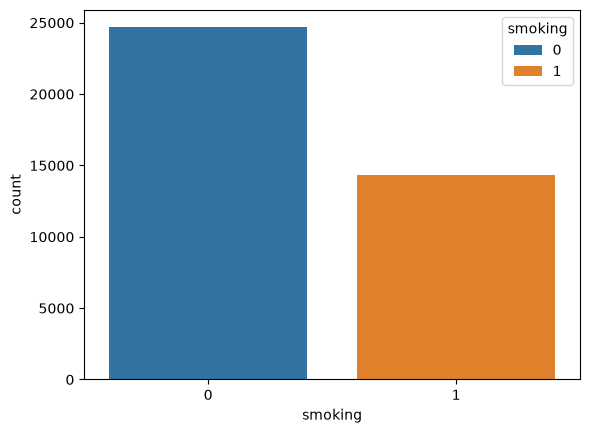

In [113]:
# Analisis de la distribución de la variable target "smoking"
print( df_smokers.smoking.value_counts() )
sns.countplot(x='smoking', data=df_smokers, hue='smoking', legend=True)

[]

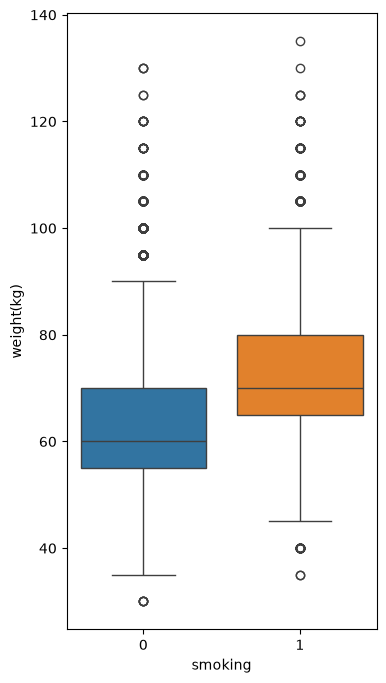

In [114]:
plt.figure(figsize=(4, 8))
s=sns.boxplot(x="smoking", y="weight(kg)", data=df_smokers, hue="smoking", legend=False)
s.plot()

# Correlación de Variables

<Axes: >

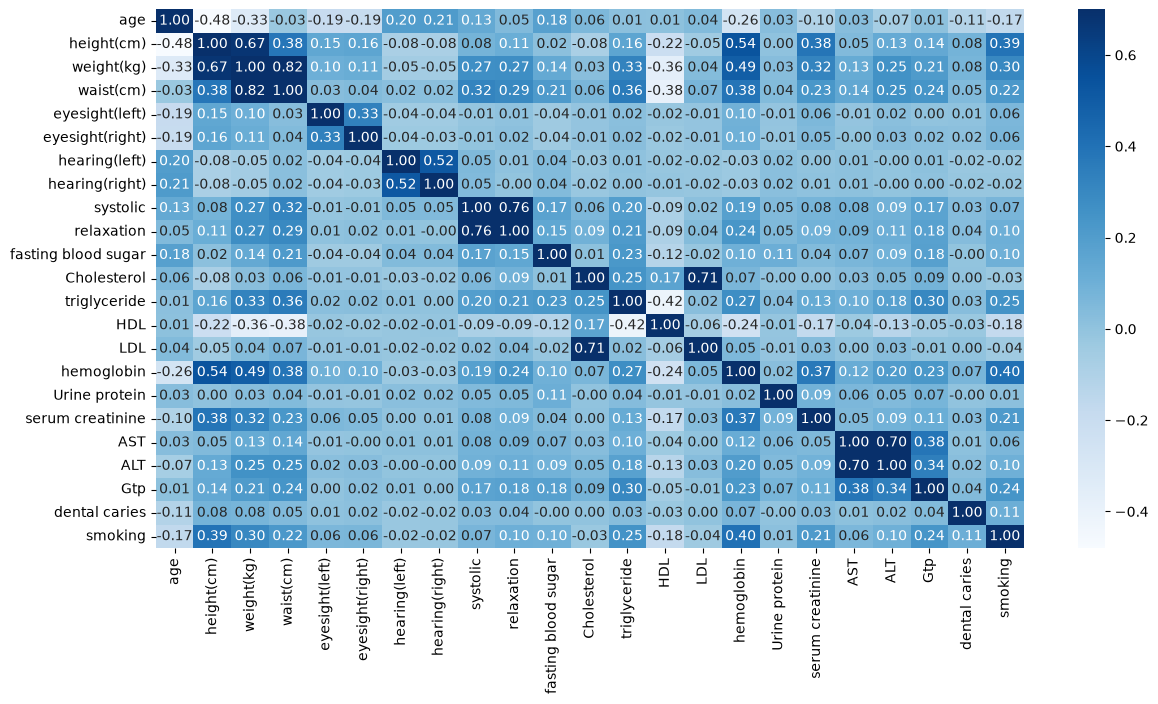

In [115]:
plt.figure(figsize=(14,7))
sns.heatmap(df_smokers.corr(), annot=True, vmax=.7, cmap ='Blues', fmt=".2f")

In [116]:
df_smokers_corr = df_smokers.corr()[["smoking"]]*100 # lo pasamos a porcentajes
print(df_smokers_corr)
df_smokers_corr = df_smokers_corr.drop("smoking", axis=0) # eliminamos la variable target
df_smokers_corr = df_smokers_corr.sort_values(["smoking"], ascending=False) # ordenamos en forma descendente
df_smokers_corr = abs(df_smokers_corr) # nos interesa el valor absouluto
df_smokers_corr

                        smoking
age                  -16.626845
height(cm)            39.431445
weight(kg)            29.934668
waist(cm)             22.335903
eyesight(left)         5.940882
eyesight(right)        6.458676
hearing(left)         -2.207703
hearing(right)        -1.898955
systolic               7.017624
relaxation            10.366297
fasting blood sugar    9.990846
Cholesterol           -2.749314
triglyceride          25.105661
HDL                  -17.950944
LDL                   -4.162746
hemoglobin            40.120561
Urine protein          1.365274
serum creatinine      21.247301
AST                    6.283387
ALT                    9.861475
Gtp                   24.027443
dental caries         10.760060
smoking              100.000000


,smoking
hemoglobin,40.120561
height(cm),39.431445
weight(kg),29.934668
triglyceride,25.105661
Gtp,24.027443
waist(cm),22.335903
serum creatinine,21.247301
dental caries,10.760060
relaxation,10.366297
fasting blood sugar,9.990846


# Seleccionamos y Escalamos las variables que vamos a utilizar

In [117]:
# definimos df con las 10 columnas que elegimos para el modelo
# sería lo mismo que hacer un drop de las que no queremos
df = df_smokers[['hemoglobin', 'height(cm)', 'weight(kg)', 'triglyceride', 'Gtp',
       'waist(cm)', 'serum creatinine', 'dental caries', 'relaxation',
       'fasting blood sugar','smoking']]

In [118]:
# Hacemos el Split 70-30 para train-test
y_smokers = df["smoking"]
X_train, X_test, y_train, y_test = train_test_split(df.drop(["smoking"],axis = 1), y_smokers, test_size=0.3, stratify = y_smokers, random_state=42)

In [119]:
# usamos StandardScaler para escalar las variables
scaler_X = StandardScaler(with_mean=True, with_std=True)
scaler_X.fit(X_train) # entrenamos los valores quitandole la variable clase

StandardScaler()

In [120]:
X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)

In [121]:
test_scores = []

# Creamos y entrenamos el algoritmo con 20 valores de K
for k in range(3,40,2):
  knn = KNeighborsClassifier(k)
  knn.fit(X_train,y_train) # Creamos y entrenamos el clasificador knn

  # Para cada valor de K, evaluamos la capacidad de clasificación con datos de prueba
  y_pred = knn.predict(X_test)
  test_scores.append(accuracy_score(y_test, y_pred)) # Agregamos los K resultados de evaluación

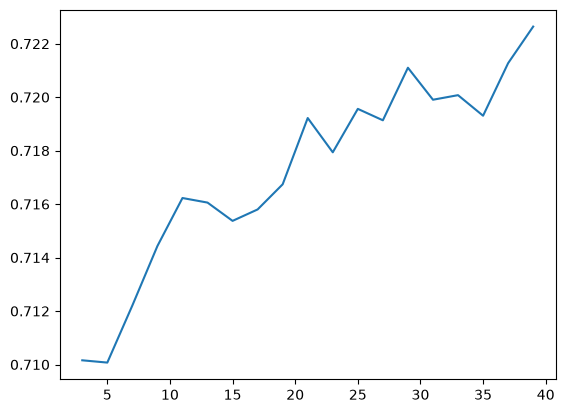

In [122]:
df_scores = pd.DataFrame([{"k":valor_k, "score":test_scores_k} for valor_k, test_scores_k in zip(range(3,40,2),test_scores)])
plt.plot(df_scores["k"], df_scores["score"])

In [123]:
df_scores

,k,score
0,3,0.710157
1,5,0.710072
2,7,0.712209
3,9,0.714432
4,11,0.716228
5,13,0.716057
6,15,0.715373
7,17,0.715800
8,19,0.716741
9,21,0.719220


In [124]:
# Entrenamos el algoritmo con el mejor K
knn = KNeighborsClassifier( 11 )
knn.fit(X_train,y_train) # Entrenamos el clasificador

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [125]:
y_pred_knn = knn.predict(X_test)

#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_knn)*100))
print("-"*100)

# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_knn))

Exactitud (accuracy) del modelo: 71.62 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      7400
           1       0.62      0.61      0.61      4296

    accuracy                           0.72     11696
   macro avg       0.69      0.69      0.69     11696
weighted avg       0.72      0.72      0.72     11696



# Ejercicio
Dado el análisis exploratorio concluimos que no hace falta imputar variables y que la variable target esta balanceada.
- Usando el mapa de calor de correlaciones, ¿que pares de columnas comparten más de un 0.7 de correlación?
- Entrenar un modelo con K distinto a 11, comparar los resultados
- Entrenar un modelo con 3 variables, seleccionar un K apropiado y comparar los resultados
- Entrenar un modelo con todas las variables, seleccionar un K apropiado y comparar los resultados
- "Feature Engineering", Crear una columna nueva no redundante, entrenar un modelo y comparar los resultados

In [126]:
corr = df_smokers.corr(numeric_only=True)

df_correlaciones = (
    corr[corr > 0.7]
    .stack()
    .reset_index(name="correlacion")
)

df_correlaciones.columns = ["columna_1", "columna_2", "correlacion"]

df_correlaciones.dropna(subset=["correlacion"]).query("correlacion < 1").sort_values(by="correlacion", ascending=False)

,columna_1,columna_2,correlacion
49,weight(kg),waist(cm),0.824865
71,waist(cm),weight(kg),0.824865
193,systolic,relaxation,0.759041
215,relaxation,systolic,0.759041
267,Cholesterol,LDL,0.707040
333,LDL,Cholesterol,0.707040


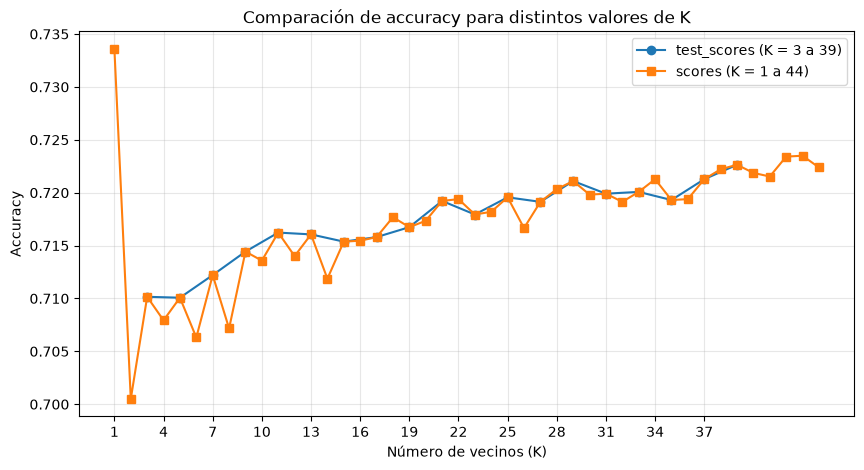

In [127]:
# Entrenar un modelo con K distinto a 11, comparar los resultados
scores = []
k_scores = range(1, 45, 1)
# Creamos y entrenamos el algoritmo con 3 valores de K
for k in k_scores:
  knn = KNeighborsClassifier(k)
  knn.fit(X_train,y_train) # Creamos y entrenamos el clasificador knn

  # Para cada valor de K, evaluamos la capacidad de clasificación con datos de prueba
  y_pred = knn.predict(X_test)
  scores.append(accuracy_score(y_test, y_pred)) # Agregamos los K resultados de evaluación


# Graficar ambos conjuntos de resultados sobre los mismos ejes
k_test_scores = range(3, 40, 2)

plt.figure(figsize=(10, 5))
plt.plot(k_test_scores, test_scores, marker="o", label="test_scores (K = 3 a 39)")
plt.plot(k_scores, scores, marker="s", label="scores (K = 1 a 44)")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 40, 3))
plt.title("Comparación de accuracy para distintos valores de K")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

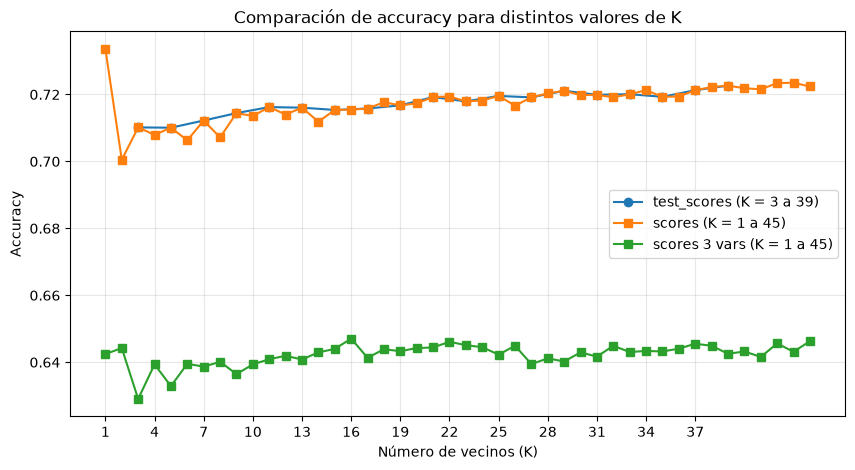

In [128]:
# - Entrenar un modelo con 3 variables, seleccionar un K apropiado y comparar los resultados
df_3vars = df_smokers[['weight(kg)', 'systolic','LDL','smoking']]
y_3smokers = df_3vars["smoking"]
X_train, X_test, y_train, y_test = train_test_split(df_3vars.drop(["smoking"],axis = 1), y_3smokers, test_size=0.3, stratify = y_3smokers, random_state=42)

scaler_X = StandardScaler(with_mean=True, with_std=True)
scaler_X.fit(X_train) # entrenamos los valores quitandole la variable clase

X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)



var_3_scores = []
for k in k_scores:
  knn = KNeighborsClassifier(k)
  knn.fit(X_train,y_train) # Creamos y entrenamos el clasificador knn

  # Para cada valor de K, evaluamos la capacidad de clasificación con datos de prueba
  y_pred = knn.predict(X_test)
  var_3_scores.append(accuracy_score(y_test, y_pred)) # Agregamos los K resultados de evaluación


# Graficar ambos conjuntos de resultados sobre los mismos ejes
k_test_scores = range(3, 40, 2)

plt.figure(figsize=(10, 5))
plt.plot(k_test_scores, test_scores, marker="o", label="test_scores (K = 3 a 39)")
plt.plot(k_scores, scores, marker="s", label="scores (K = 1 a 45)")
plt.plot(k_scores, var_3_scores, marker="s", label="scores 3 vars (K = 1 a 45)")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 40, 3))
plt.title("Comparación de accuracy para distintos valores de K")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

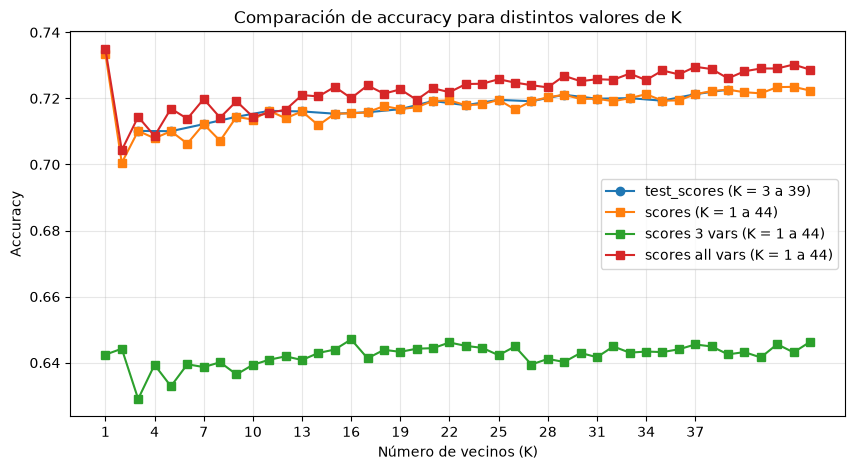

In [129]:
# Entrenar un modelo con todas las variables, seleccionar un K apropiado y comparar los resultados
all_smokers = df_smokers["smoking"]
X_train, X_test, y_train, y_test = train_test_split(df_smokers.drop(["smoking"],axis = 1), all_smokers, test_size=0.3, stratify = all_smokers, random_state=42)

scaler_X = StandardScaler(with_mean=True, with_std=True)
scaler_X.fit(X_train) # entrenamos los valores quitandole la variable clase

X_train = scaler_X.transform(X_train)
X_test = scaler_X.transform(X_test)

all_scores = []
for k in k_scores:
  knn = KNeighborsClassifier(k)
  knn.fit(X_train,y_train) # Creamos y entrenamos el clasificador knn

  # Para cada valor de K, evaluamos la capacidad de clasificación con datos de prueba
  y_pred = knn.predict(X_test)
  all_scores.append(accuracy_score(y_test, y_pred)) # Agregamos los K resultados de evaluación


# Graficar ambos conjuntos de resultados sobre los mismos ejes
plt.figure(figsize=(10, 5))
plt.plot(k_test_scores, test_scores, marker="o", label="test_scores (K = 3 a 39)")
plt.plot(k_scores, scores, marker="s", label="scores (K = 1 a 44)")
plt.plot(k_scores, var_3_scores, marker="s", label="scores 3 vars (K = 1 a 44)")
plt.plot(k_scores, all_scores, marker="s", label="scores all vars (K = 1 a 44)")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 40, 3))
plt.title("Comparación de accuracy para distintos valores de K")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [131]:
# "Feature Engineering", Crear una columna nueva no redundante, entrenar un modelo y comparar los resultados

# Feature Engineering: BMI instead of raw weight
df_engineered = df_smokers[["systolic", "LDL", "smoking"]].copy()

df_engineered["BMI"] = (
    df_smokers["weight(kg)"] / (df_smokers["height(cm)"] / 100) ** 2
)

X_engineered = df_engineered.drop(columns="smoking")
y_engineered = df_engineered["smoking"]

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.3,
    stratify=y_engineered,
    random_state=42
)

scaler_eng = StandardScaler()
X_train_eng = scaler_eng.fit_transform(X_train_eng)
X_test_eng = scaler_eng.transform(X_test_eng)

engineered_scores = []

for k in k_scores:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_eng, y_train_eng)

    y_pred_eng = knn.predict(X_test_eng)
    engineered_scores.append(accuracy_score(y_test_eng, y_pred_eng))


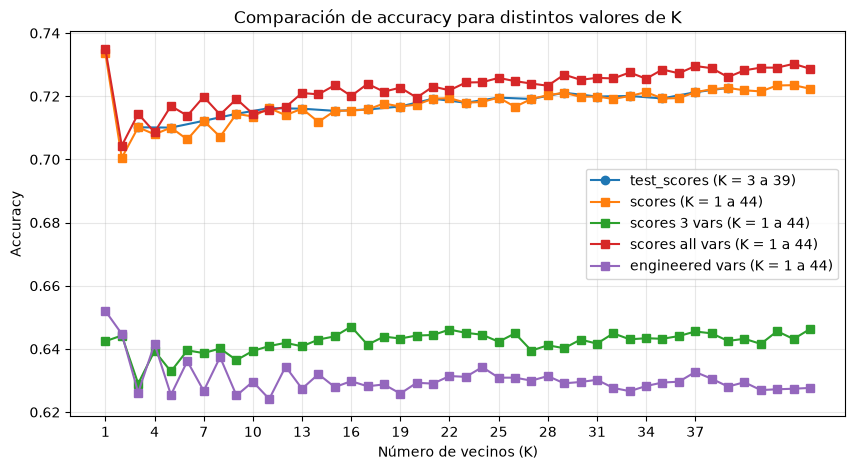

In [132]:
plt.figure(figsize=(10, 5))
plt.plot(k_test_scores, test_scores, marker="o", label="test_scores (K = 3 a 39)")
plt.plot(k_scores, scores, marker="s", label="scores (K = 1 a 44)")
plt.plot(k_scores, var_3_scores, marker="s", label="scores 3 vars (K = 1 a 44)")
plt.plot(k_scores, all_scores, marker="s", label="scores all vars (K = 1 a 44)")
plt.plot(k_scores, engineered_scores, marker="s", label="engineered vars (K = 1 a 44)")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 40, 3))
plt.title("Comparación de accuracy para distintos valores de K")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()